In [ ]:
import numpy as np
from scipy.optimize import least_squares
import pandas as pd

# Load points from CSV
points = pd.read_csv("/content/Results.csv")
x, y = points['X'], points['Y']

# Circle fitting function
def residuals(params, x, y):
    xc, yc, r = params
    return np.sqrt((x - xc)**2 + (y - yc)**2) - r

# Initial guess: center at mean, radius ~ mean distance
x0, y0 = np.mean(x), np.mean(y)
r0 = np.mean(np.sqrt((x - x0)**2 + (y - y0)**2))
params0 = [x0, y0, r0]

res = least_squares(residuals, params0, args=(x, y))
xc, yc, r = res.x

print(f"Circle center: ({xc:.2f}, {yc:.2f}), radius: {r:.2f}")


Circle center: (51.47, 63.15), radius: 42.10


In [ ]:
points.head(10)

,,Label,Area,X,Y,Major,Minor,Angle,Length,Unnamed: 9
0,1,100mW nile red-01162026102129-0000.avi:0.01 s,2.231,31.032,20.903,0,0,3.442,17.192,diamter
1,2,100mW nile red-01162026102129-0000.avi:0.01 s,7.659,41.742,29.613,0,0,-84.873,59.205,NaN
2,3,200mW nile red-01162026102300-0000.avi:0.01 s,2.314,29.548,36.258,0,0,3.318,17.836,diameter
3,4,200mW nile red-01162026102300-0000.avi:0.01 s,7.442,39.032,29.226,0,0,-85.759,57.577,NaN
4,5,300mW nile red-01162026102806-0000.avi:0.01 s,2.281,38.581,26.581,0,0,21.644,17.491,diameter
5,6,300mW nile red-01162026102806-0000.avi:0.01 s,6.909,27.677,25.742,0,0,-67.092,53.370,NaN
6,7,400mW nile red-01162026103350-0000.avi:0.01 s,2.414,41.032,26.194,0,0,3.180,18.609,diameter
7,8,400mW nile red-01162026103350-0000.avi:0.01 s,8.807,56.903,33.806,0,0,-81.287,68.141,NaN
8,9,500mW nile red-01162026103655-0000.avi:0.01 s,2.564,35.032,22.387,0,0,26.061,19.678,diameter
9,10,500mW nile red-01162026103655-0000.avi:0.01 s,6.909,23.355,23.226,0,0,-58.846,53.375,NaN


In [ ]:
import numpy as np

# ===============================
# INPUTS
# ===============================

# Video-extracted geometry (pixels)
radii_px = np.array([5.138])
lengths_px = np.array([66.168])
pixel_size_um = 7.95  # µm / pixel
# Laser power
laser_power_W =1.0# W
laser_power_err_W = 0.005  # W (power meter uncertainty)

# Trap calibration (force per watt)
alpha = 1.53e-11           # N/W
alpha_err = 0.15e-11       # N/W

# Geometry constant
C = 1.0

# ===============================
# GEOMETRY FROM VIDEO
# ===============================

radii_um = radii_px
lengths_um = lengths_px

R_um = np.mean(radii_um)
L_um = np.mean(lengths_um)

def sem(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

R_err_um = sem(radii_um)
L_err_um = sem(lengths_um)

R = R_um * 1e-6
L = L_um * 1e-6
R_err = R_err_um * 1e-6
L_err = L_err_um * 1e-6

# ===============================
# FORCE FROM LASER POWER
# ===============================

F = alpha * laser_power_W

F_err = F * np.sqrt(
    (alpha_err / alpha)**2 +
    (laser_power_err_W / laser_power_W)**2
)

# ===============================
# BENDING MODULUS
# ===============================

k_c = F * R**2 / (2 * np.pi * L)

# ===============================
# ERROR PROPAGATION
# ===============================

# ===============================
# OUTPUT
# ===============================

print("=================================")
print("Elastic Modulus from Optical Trap")
print("=================================")
print(f"Laser Power: {laser_power_W*1000:.0f} ± {laser_power_err_W*1000:.0f} mW")
print(f"Radius R: {R_um:.2f} ± {R_err_um:.2f} µm")
print(f"Length L: {L_um:.2f} ± {L_err_um:.2f} µm")
print(f"Force F: {F:.2e} ± {F_err:.2e} N")
print(f"Bending modulus k_c: {k_c:.2e}J")


Elastic Modulus from Optical Trap
Laser Power: 1000 ± 5 mW
Radius R: 5.14 ± 0.00 µm
Length L: 66.17 ± 0.00 µm
Force F: 1.53e-11 ± 1.50e-12 N
Bending modulus k_c: 9.72e-19J


In [ ]:
1/5.138**2

0.03788015959971884

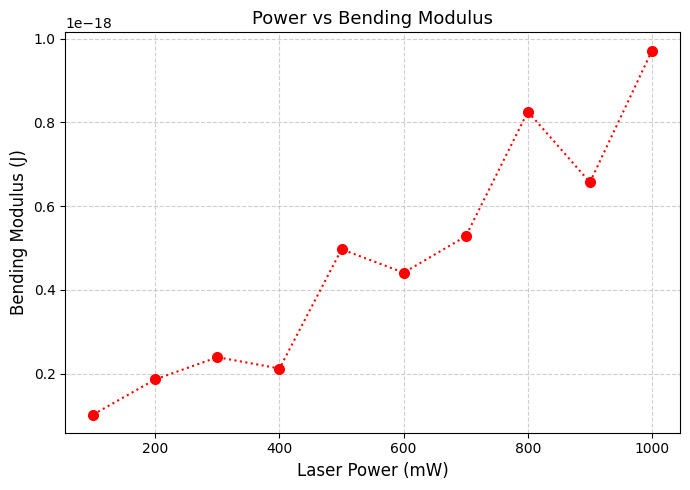

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Power values
power = np.arange(100, 1100, 100)

# Bending modulus data
kc = np.array([
1.02E-19,
1.86E-19,
2.39E-19,
2.12E-19,
4.97E-19,
4.41E-19,
5.28E-19,
8.26E-19,
6.57E-19,
9.72E-19

])

# Plot dotted line with dots
plt.figure(figsize=(7,5))
plt.plot(power, kc, marker='o', linestyle=':', linewidth=1.5,color='red',markersize=7)

plt.xlabel("Laser Power (mW)", fontsize=12)
plt.ylabel("Bending Modulus (J)", fontsize=12)
plt.title("Power vs Bending Modulus", fontsize=13)

plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import math
s=1.28e-18+1.94e-18
v=s/2
print(v)

1.61e-18


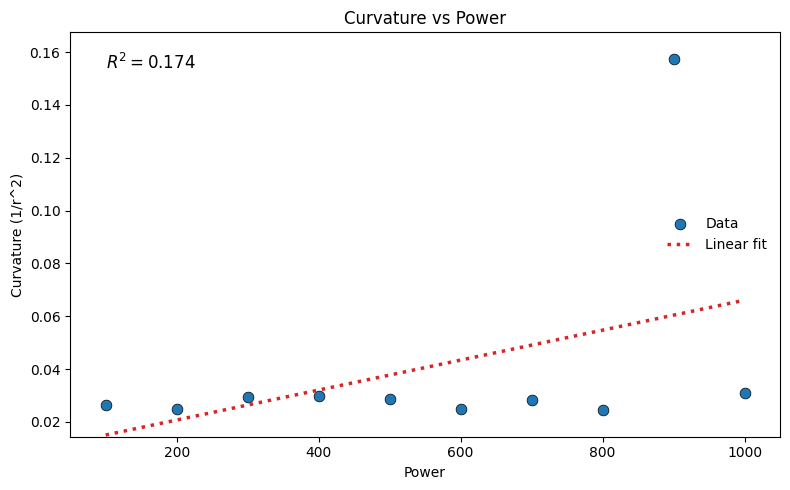

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Data (same values)
x = np.array([100, 200, 300, 400, 500, 600, 700, 800, 900,1000])
y = np.array([
    0.026352,
    0.02497,
    0.029538,
    0.029706,
    0.02871,
    0.025011,
    0.028222,
    0.024365,
    0.157466,
    0.031044

 ])

# Linear regression
coeffs = np.polyfit(x, y, 1)
trendline = np.poly1d(coeffs)

# R^2 calculation
y_pred = trendline(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    x, y,
    s=60,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.5,
    label="Data"
)

plt.plot(
    x, trendline(x),
    linestyle=":",
    linewidth=2.5,
    color="#d62728",
    label="Linear fit"
)

# Labels and title
plt.xlabel("Power")
plt.ylabel("Curvature (1/r^2)")
plt.title("Curvature vs Power")

# Axis scaling
plt.xlim(min(x) - 50, max(x) + 50)
plt.ylim(min(y) - 0.01, max(y) + 0.01)

# R^2 annotation
plt.text(
    0.05, 0.95,
    f"$R^2 = {r2:.3f}$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

# Clean look
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


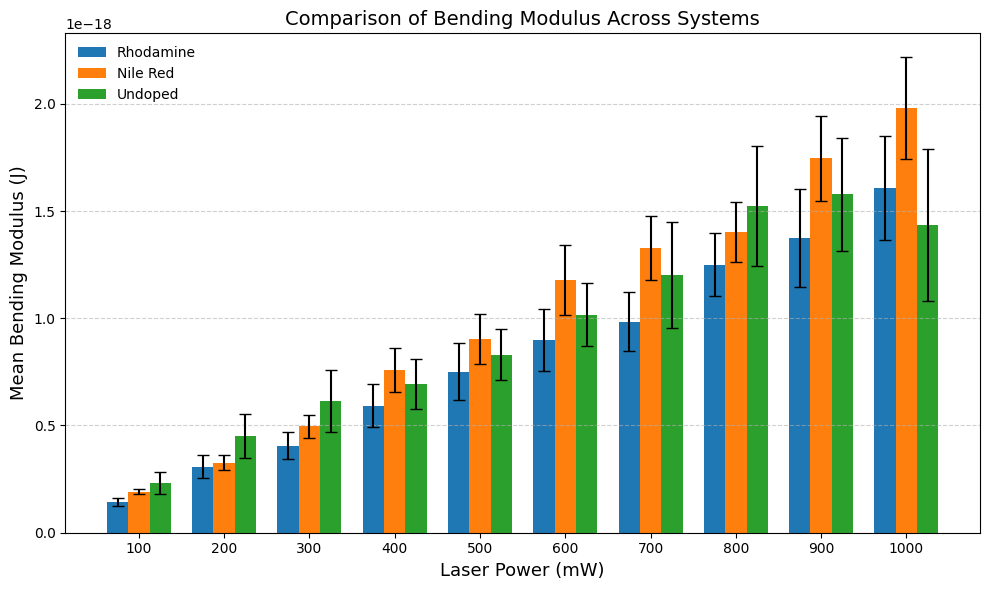

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

powers = np.array([100,200,300,400,500,600,700,800,900,1000])

nile = np.array([
[1.86E-19,1.58E-19,1.34E-19,1.54E-19,2.21E-19,2.27E-19,2.21E-19,2.23E-19,1.87E-19],
[3.05E-19,2.38E-19,1.64E-19,3.19E-19,2.49E-19,4.07E-19,4.51E-19,4.69E-19,3.43E-19],
[4.51E-19,3.64E-19,3.18E-19,4.16E-19,3.87E-19,6.12E-19,6.11E-19,8.24E-19,4.89E-19],
[6.41E-19,4.78E-19,4.59E-19,5.77E-19,5.70E-19,9.51E-19,8.12E-19,9.33E-19,1.42E-18],
[7.62E-19,5.36E-19,5.08E-19,7.19E-19,7.51E-19,1.13E-18,9.25E-19,1.57E-18,1.23E-18],
[9.97E-19,6.58E-19,7.91E-19,9.37E-19,7.78E-19,1.48E-18,1.34E-18,1.41E-18,2.22E-18],
[1.15E-18,8.27E-19,9.68E-19,1.14E-18,9.92E-19,1.60E-18,1.40E-18,1.57E-18,2.30E-18],
[1.24E-18,9.63E-19,1.22E-18,1.20E-18,8.33E-19,1.78E-18,1.43E-18,2.05E-18,1.90E-18],
[1.50E-18,1.20E-18,1.72E-18,1.03E-18,1.28E-18,1.75E-18,2.03E-18,2.31E-18,2.90E-18],
[1.70E-18,1.58E-18,1.68E-18,1.58E-18,1.13E-18,1.95E-18,2.30E-18,3.61E-18,2.29E-18]
])

# --- Undoped ---
undoped = np.array([
[2.33E-19,1.14E-19,2.09E-19,2.74E-19,1.49E-19,7.65E-20,6.07E-19,2.85E-19,1.39E-19],
[4.69E-19,2.28E-19,3.96E-19,6.13E-19,1.99E-19,2.05E-19,1.18E-18,5.09E-19,2.61E-19],
[6.44E-19,3.32E-19,5.47E-19,9.57E-19,3.08E-19,2.80E-19,1.61E-18,5.83E-19,2.65E-19],
[8.92E-19,3.85E-19,6.88E-19,1.17E-18,4.24E-19,3.67E-19,1.18E-18,8.38E-19,3.02E-19],
[1.06E-18,3.93E-19,7.98E-19,1.45E-18,3.85E-19,7.92E-19,1.11E-18,9.78E-19,5.11E-19],
[1.47E-18,4.52E-19,9.87E-19,1.71E-18,5.60E-19,8.10E-19,1.36E-18,1.20E-18,6.02E-19],
[2.88E-18,4.59E-19,1.05E-18,1.86E-18,8.32E-19,9.38E-19,1.16E-18,1.05E-18,5.97E-19],
[2.36E-18,4.59E-19,1.34E-18,2.94E-18,8.66E-19,1.33E-18,2.12E-18,1.69E-18,6.03E-19],
[2.53E-18,4.50E-19,1.48E-18,2.74E-18,8.46E-19,1.55E-18,2.24E-18,1.47E-18,8.91E-19],
[0.00E+00,4.66E-19,1.68E-18,3.37E-18,8.70E-19,1.66E-18,2.68E-18,1.38E-18,8.02E-19]
])

# ---rhod ---
rhod= np.array([
[1.15E-19,2.38E-19,1.23E-19,1.34E-19,1.48E-19,2.28E-19,7.26E-20,1.12E-19,1.02E-19],
[2.31E-19,2.69E-19,3.39E-19,2.74E-19,2.88E-19,7.13E-19,3.09E-19,1.63E-19,1.86E-19],
[3.36E-19,3.39E-19,7.12E-19,4.84E-19,3.62E-19,7.01E-19,2.34E-19,2.42E-19,2.39E-19],
[4.44E-19,5.41E-19,9.19E-19,5.96E-19,6.16E-19,1.18E-18,4.89E-19,3.40E-19,2.12E-19],
[5.19E-19,7.32E-19,1.33E-18,9.26E-19,6.94E-19,1.40E-18,2.45E-19,4.22E-19,4.97E-19],
[6.92E-19,8.84E-19,1.34E-18,9.05E-19,7.62E-19,1.84E-18,6.26E-19,5.93E-19,4.41E-19],
[8.52E-19,1.32E-18,1.25E-18,1.42E-18,8.10E-19,1.57E-18,5.69E-19,5.29E-19,5.28E-19],
[1.00E-18,1.41E-18,1.65E-18,1.89E-18,8.71E-19,1.44E-18,1.59E-18,5.75E-19,8.26E-19],
[1.06E-18,1.68E-18,1.91E-18,1.52E-18,1.11E-18,2.76E-18,1.09E-18,5.72E-19,6.57E-19],
[1.30E-18,1.54E-18,2.31E-18,2.08E-18,1.51E-18,2.94E-18,1.24E-18,5.73E-19,9.72E-19]
])
# =========================
# COMPUTE MEAN & SEM
# =========================
def compute_stats(data):
    n = data.shape[1]
    mean = np.mean(data, axis=1)
    std = np.std(data, axis=1, ddof=1)
    sem = std / np.sqrt(n)
    return mean, sem

mean_rho, sem_rho = compute_stats(rhod)
mean_nile, sem_nile = compute_stats(nile)
mean_undoped, sem_undoped = compute_stats(undoped)

# =========================
# GROUPED BAR PLOT
# =========================
width = 25

plt.figure(figsize=(10,6))

plt.bar(powers - width, mean_rho, width=width,
        yerr=sem_rho, capsize=4, label='Rhodamine')

plt.bar(powers, mean_nile, width=width,
        yerr=sem_nile, capsize=4, label='Nile Red')

plt.bar(powers + width, mean_undoped, width=width,
        yerr=sem_undoped, capsize=4, label='Undoped')

plt.xlabel("Laser Power (mW)", fontsize=13)
plt.ylabel("Mean Bending Modulus (J)", fontsize=13)
plt.title("Comparison of Bending Modulus Across Systems", fontsize=14)

plt.xticks(powers)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

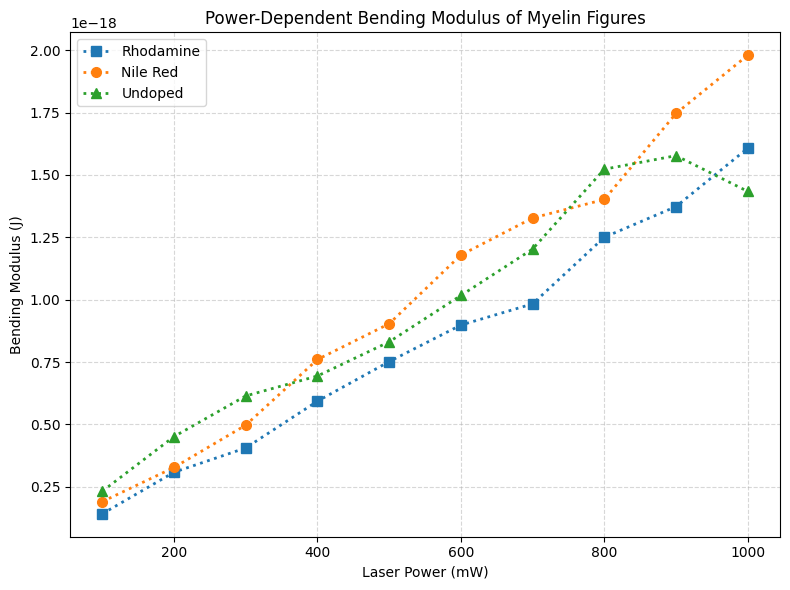

In [ ]:
# =========================
# PLOT (DOTTED LINE ONLY)
# =========================
plt.figure(figsize=(8,6))

plt.plot(powers, mean_rho, marker='s', linestyle=':', linewidth=2,
         markersize=7, label='Rhodamine')

plt.plot(powers, mean_nile, marker='o', linestyle=':', linewidth=2,
         markersize=7, label='Nile Red')

plt.plot(powers, mean_undoped, marker='^', linestyle=':', linewidth=2,
         markersize=7, label='Undoped')

plt.xlabel("Laser Power (mW)")
plt.ylabel("Bending Modulus (J)")
plt.title("Power-Dependent Bending Modulus of Myelin Figures")

plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# ======================
# DATA
# ======================

nile = np.array([
    [0.01429, 0.0215, 0.0276, 0.02695, 0.04142],
    [0.01557, 0.0131, 0.0366, 0.03482, 0.02476],
    [0.01818, 0.01313, 0.0394, 0.03716, 0.03982],
    [0.01469, 0.01278, 0.0404, 0.04678, 0.03388],
    [0.01119, 0.0138, 0.0391, 0.02729, 0.05217],
    [0.01117, 0.01088, 0.0411, 0.036545, 0.02536],
    [0.0087, 0.0119, 0.0444, 0.03611, 0.04],
    [0.008685, 0.0126, 0.0474, 0.03192, 0.02122],
    [0.008066, 0.01189, 0.0564, 0.04689, 0.03422],
    [0.0097, 0.01073, 0.0621, 0.03788, 0.03481]
])

rhod = np.array([
    [0.01496, 0.0192, 0.011748, 0.02027, 0.1508, 0.0182],
    [0.01381, 0.02623, 0.01057, 0.02276, 0.161, 0.01809],
    [0.01366, 0.0207, 0.01051, 0.0254, 0.1451, 0.01816],
    [0.01482, 0.01926, 0.010165, 0.024, 0.1351, 0.01741],
    [0.01293, 0.02227, 0.0088, 0.02692, 0.139, 0.010009],
    [0.01361, 0.01675, 0.015878, 0.02418, 0.1369, 0.009502],
    [0.01238, 0.01598, 0.013585, 0.0446, 0.1309, 0.01317],
    [0.01289, 0.01368, 0.010778, 0.03959, 0.1288, 0.01072],
    [0.01766, 0.01111, 0.0108, 0.03098, 0.1205, 0.01028],
    [0.01317, 0.01228, 0.009285, 0.03511, 0.1071, 0.01192]
])

undoped = np.array([
    [0.02123, 0.008606, 0.0056, 0.11345],
    [0.02307, 0.008416, 0.005967, 0.1197],
    [0.02879, 0.01285, 0.005782, 0.11084],
    [0.03529, 0.011149, 0.010123, 0.10739],
    [0.03389, 0.01287, 0.009695, 0.11028],
    [0.03774, 0.01613, 0.010507, 0.10432],
    [0.0381, 0.01959, 0.010755, 0.0996],
    [0.03649, 0.01354, 0.0115447, 0.09307],
    [0.02849, 0.01831, 0.01296, 0.08983],
    [0.03011, 0.0227, 0.01202, 0.086077]
])

# ======================
# FLATTEN DATA
# ======================

nile_flat = nile.flatten()
rhod_flat = rhod.flatten()
undoped_flat = undoped.flatten()

# ======================
# MEAN + ERROR
# ======================

def stats(data):
    mean = np.mean(data)
    std = np.std(data)
    sem = std / np.sqrt(len(data))
    return mean, std, sem

nile_mean, nile_std, nile_sem = stats(nile_flat)
rhod_mean, rhod_std, rhod_sem = stats(rhod_flat)
und_mean, und_std, und_sem = stats(undoped_flat)

# ======================
# PRINT RESULTS
# ======================

print("Nile Red:")
print(f"Mean = {nile_mean:.5f}, SD = {nile_std:.5f}, SEM = {nile_sem:.5f}")

print("\nRhodamine:")
print(f"Mean = {rhod_mean:.5f}, SD = {rhod_std:.5f}, SEM = {rhod_sem:.5f}")

print("\nUndoped:")
print(f"Mean = {und_mean:.5f}, SD = {und_std:.5f}, SEM = {und_sem:.5f}")

Nile Red:
Mean = 0.02794, SD = 0.01450, SEM = 0.00205

Rhodamine:
Mean = 0.03693, SD = 0.04505, SEM = 0.00582

Undoped:
Mean = 0.03967, SD = 0.03826, SEM = 0.00605


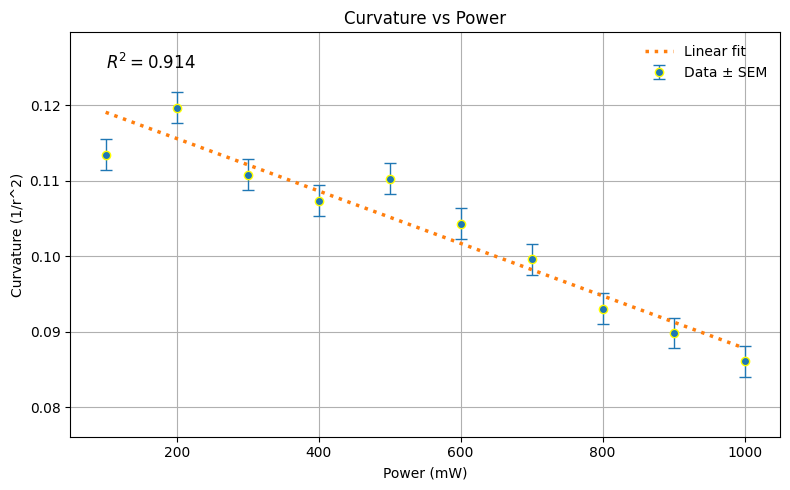

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.array([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
y = np.array([
0.11345,
0.1197,
0.11084,
0.10739,
0.11028,
0.10432,
0.0996,
0.09307,
0.08983,
0.086077
])

# Error (SEM)
SEM =  0.00205
yerr = np.full_like(y, SEM)

# Linear regression
coeffs = np.polyfit(x, y, 1)
trendline = np.poly1d(coeffs)

# R^2 calculation
y_pred = trendline(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

# Plot
plt.figure(figsize=(8, 5))

# 🔹 Error bars + markers (NO line between points)
plt.errorbar(
    x, y,
    yerr=yerr,
    fmt='o',              # markers only
    markersize=6,
    capsize=4,
    elinewidth=1,
    markeredgecolor='yellow',
    label="Data ± SEM"
)

# 🔹 Linear fit (separate line)
plt.plot(
    x, trendline(x),
    linestyle=":",
    linewidth=2.5,
    label="Linear fit"
)

# Labels and title
plt.xlabel("Power (mW)")
plt.ylabel("Curvature (1/r^2)")
plt.title("Curvature vs Power")

# Axis scaling
plt.xlim(min(x) - 50, max(x) + 50)
plt.ylim(min(y) - 0.01, max(y) + 0.01)

# R^2 annotation
plt.text(
    0.05, 0.95,
    f"$R^2 = {r2:.3f}$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

# Clean look
plt.legend(frameon=False)
plt.tight_layout()
plt.grid(True)

plt.show()